**Jason Scott, DATASCI W210, SPRING 2026**

# Modeling Pipeline for FMA + Ads Datasets

## 1: V1 - Feature Engineering & Euclidean Distance Matching

This section builds the v1 music-to-ad matching pipeline using Echonest audio features from
the FMA dataset and synthetic ad annotations.

### Steps
1. Load FMA track data and ad annotations from S3
2. Engineer popularity features using log1p transform and quartile bucketing
3. Validate Echonest feature scales and normalize tempo to 0-1
4. Convert ad annotations to numeric target vectors using fixed midpoint mappings
5. Build Euclidean distance matching function with indie popularity boost
6. Run matching across all 300 ads and evaluate coverage and diversity
7. Save `v1_matches_with_meta.csv` to S3

### Data Sources
- **FMA track data** (`fma_pre_z.csv`): 13,129 tracks with 8 Echonest audio features in original scale (0-1)
- **Ad annotations** (`ads_df_post_eda.csv`): 300 ads annotated across Energy (1-5), Tempo (Slow/Medium/Fast), and Mood (Positive/Neutral/Serious)

### Evaluation Metrics

| Metric | Target | V1 Result |
|--------|--------|-----------|
| Coverage (≥10 matches per ad) | >90% | 100% (300/300) |
| Artist diversity (unique per top-10) | >0.7 | 0.995 |
| Match score range | <0.3 | 0.004–0.099 |
| Human listening score | >3.5/5 | TBD |

&nbsp;


In [6]:
!pip install boto3 -q
!pip install h5py -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.5 MB/s eta 0:00:00


In [7]:
# =================================================================
# 1.1) SETUP & DATA LOADING
# =================================================================

import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

# S3 setup
print("Connecting to S3...")
s3 = boto3.client(
    's3',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=userdata.get('AWS_SECRET_ACCESS_KEY'),
    region_name='us-west-2'
)
print("S3 connection established.")

BUCKET = 'mids-capstone-music-ad-matching-2026'

# Download datasets from S3
print("\nDownloading datasets from S3...")
s3.download_file(BUCKET, 'processed-data/fma/fma_pre_z.csv', 'fma.csv')
print("- fma_pre_z.csv downloaded.")
s3.download_file(BUCKET, 'processed-data/synthetic-annotations/ads_df_post_eda.csv', 'ads.csv')
print("- ads_df_post_eda.csv downloaded.")

# Load data
print("\nLoading data into dataframes...")
df_fma = pd.read_csv('fma.csv')
df_ads = pd.read_csv('ads.csv')
print(f"- FMA: {df_fma.shape}")
print(f"- Ads: {df_ads.shape}")
print("Data loading complete.\n")

Connecting to S3...
S3 connection established.

- fma_pre_z.csv downloaded.
- ads_df_post_eda.csv downloaded.

Loading data into dataframes...
- FMA: (13129, 821)
- Ads: (300, 15)
Data loading complete.



/tmp/ipython-input-6448/2468721144.py:33: DtypeWarning: Columns (42,47,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fma = pd.read_csv('fma.csv')


In [8]:
# =================================================================
# 1.2) FMA POPULARITY FEATURE ENGINEERING
# =================================================================

print("\nEngineering popularity features...")

# Log transform
df_fma['log_track_listens'] = np.log1p(df_fma['track_listens'])
df_fma['log_track_favorites'] = np.log1p(df_fma['track_favorites'])
print("- Log transform applied to track_listens and track_favorites.")

# Popularity bucket
df_fma['popularity_bucket'] = pd.qcut(
    df_fma['log_track_listens'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)
print("- Popularity buckets created.\n")

print(df_fma[['log_track_listens', 'log_track_favorites', 'popularity_bucket']].describe())
print("\nBucket distribution:")
print(df_fma['popularity_bucket'].value_counts().sort_index())


Engineering popularity features...
- Log transform applied to track_listens and track_favorites.
- Popularity buckets created.

       log_track_listens  log_track_favorites
count       13129.000000         13129.000000
mean            6.619078             1.028984
std             1.301272             0.925899
min             2.564949             0.000000
25%             5.703782             0.000000
50%             6.543912             0.693147
75%             7.447168             1.609438
max            13.205330             7.301822

Bucket distribution:
popularity_bucket
Low         3290
Mid-Low     3282
Mid-High    3280
High        3277
Name: count, dtype: int64


In [9]:
# =================================================================
# 1.3) FMA FEATURE SCALE VALIDATION + TEMPO NORMALIZATION (0-1)
# =================================================================

print("\nValidating feature scales...")

ECHONEST_FEATURES = [
    'echonest_audio_features_acousticness',
    'echonest_audio_features_danceability',
    'echonest_audio_features_energy',
    'echonest_audio_features_instrumentalness',
    'echonest_audio_features_liveness',
    'echonest_audio_features_speechiness',
    'echonest_audio_features_tempo',
    'echonest_audio_features_valence'
]

POPULARITY_COLS = ['log_track_listens', 'log_track_favorites', 'popularity_bucket']

df_features = df_fma[ECHONEST_FEATURES + POPULARITY_COLS].copy()

print("=== Scale Check (echonest features) ===")
for col in ECHONEST_FEATURES:
    print(f"  {col.replace('echonest_audio_features_', '')}: "
          f"min={df_features[col].min():.3f}, "
          f"max={df_features[col].max():.3f}, "
          f"mean={df_features[col].mean():.3f}")

print("\nNormalizing tempo to 0-1 scale...")
TEMPO_MIN = df_features['echonest_audio_features_tempo'].min()
TEMPO_MAX = df_features['echonest_audio_features_tempo'].max()

df_features['echonest_audio_features_tempo_norm'] = (
    (df_features['echonest_audio_features_tempo'] - TEMPO_MIN) / (TEMPO_MAX - TEMPO_MIN)
)

print(f"  Tempo normalized — min: {df_features['echonest_audio_features_tempo_norm'].min():.3f}, "
      f"max: {df_features['echonest_audio_features_tempo_norm'].max():.3f}")


Validating feature scales...
=== Scale Check (echonest features) ===
  acousticness: min=0.000, max=0.996, mean=0.525
  danceability: min=0.051, max=0.969, mean=0.487
  energy: min=0.000, max=1.000, mean=0.538
  instrumentalness: min=0.000, max=0.998, mean=0.641
  liveness: min=0.025, max=0.980, mean=0.188
  speechiness: min=0.022, max=0.966, mean=0.099
  tempo: min=12.753, max=251.072, mean=123.080
  valence: min=0.000, max=1.000, mean=0.440

Normalizing tempo to 0-1 scale...
  Tempo normalized — min: 0.000, max: 1.000


In [10]:
# =================================================================
# 1.4) AD FEATURE VECTOR CONSTRUCTION
# =================================================================

print("\nConstructing ad feature vectors...")

ENERGY_MAP = {1: 0.1, 2: 0.3, 3: 0.5, 4: 0.7, 5: 0.9}

TEMPO_MAP = {
    'Slow':   (70 - TEMPO_MIN) / (TEMPO_MAX - TEMPO_MIN),
    'Medium': (115 - TEMPO_MIN) / (TEMPO_MAX - TEMPO_MIN),
    'Fast':   (190 - TEMPO_MIN) / (TEMPO_MAX - TEMPO_MIN)
}

MOOD_MAP = {'Positive': 0.75, 'Neutral': 0.5, 'Serious': 0.25}

df_ads['target_energy'] = df_ads['energy_1_5'].map(ENERGY_MAP)
df_ads['target_tempo']  = df_ads['tempo'].map(TEMPO_MAP)
df_ads['target_valence'] = df_ads['mood'].map(MOOD_MAP)

print("Vector construction complete.")

print("\n=== Ad Feature Vector Sample ===")
print(df_ads[['ad_id', 'energy_1_5', 'tempo', 'mood',
              'target_energy', 'target_tempo', 'target_valence']].head(5))

print("\nNull check:")
print(df_ads[['target_energy', 'target_tempo', 'target_valence']].isnull().sum())



Constructing ad feature vectors...
Vector construction complete.

=== Ad Feature Vector Sample ===
    ad_id  energy_1_5   tempo      mood  target_energy  target_tempo  \
0  JS_001           4  Medium  Positive            0.7      0.429034   
1  JS_002           5    Fast  Positive            0.9      0.743738   
2  JS_003           2    Slow  Positive            0.3      0.240212   
3  JS_004           3  Medium  Positive            0.5      0.429034   
4  JS_005           5    Fast  Positive            0.9      0.743738   

   target_valence  
0            0.75  
1            0.75  
2            0.75  
3            0.75  
4            0.75  

Null check:
target_energy     0
target_tempo      0
target_valence    0
dtype: int64


In [11]:
# =================================================================
# 1.5) MATCHING FUNCTION (V1 - Euclidean Distance)
# =================================================================

print("\nDefining V1 matching function...")

POPULARITY_PENALTY = 0.20

def match_tracks(ad_row, df_tracks, top_n=10):
    scores = np.zeros(len(df_tracks))

    scores += (df_tracks['echonest_audio_features_energy'].values - ad_row['target_energy']) ** 2
    scores += (df_tracks['echonest_audio_features_tempo_norm'].values - ad_row['target_tempo']) ** 2
    scores += (df_tracks['echonest_audio_features_valence'].values - ad_row['target_valence']) ** 2

    scores = np.sqrt(scores)

    high_mask = df_tracks['popularity_bucket'].values == 'High'
    scores[high_mask] *= (1 + POPULARITY_PENALTY)

    results = df_tracks.copy()
    results['match_score'] = scores
    return results.nsmallest(top_n, 'match_score')[
        ['match_score', 'popularity_bucket',
         'echonest_audio_features_energy',
         'echonest_audio_features_tempo_norm',
         'echonest_audio_features_valence']
    ].reset_index()

print("Function definition complete.")

# Test on first ad
test_ad = df_ads.iloc[0]
print(f"\nTest run — Ad: {test_ad['ad_id']} | Energy={test_ad['energy_1_5']} | "
      f"Tempo={test_ad['tempo']} | Mood={test_ad['mood']}")
top_matches = match_tracks(test_ad, df_features)
print(f"\nTop 10 Matches:")
print(top_matches)


Defining V1 matching function...
Function definition complete.

Test run — Ad: JS_001 | Energy=4 | Tempo=Medium | Mood=Positive

Top 10 Matches:
   index  match_score popularity_bucket  echonest_audio_features_energy  \
0   7021     0.013291               Low                        0.701927   
1   8487     0.022406               Low                        0.696592   
2  12760     0.023228          Mid-High                        0.700277   
3   3402     0.027047              High                        0.691026   
4  10643     0.031077           Mid-Low                        0.693947   
5  12527     0.032262           Mid-Low                        0.670842   
6   4007     0.035103           Mid-Low                        0.681433   
7   4448     0.035384               Low                        0.732042   
8  12281     0.041093          Mid-High                        0.700450   
9  12640     0.044796          Mid-High                        0.698086   

   echonest_audio_features_t

In [12]:
# =================================================================
# 1.6) RUN MATCHING ACROSS ALL 300 ADS + COVERAGE/DIVERSITY CHECK
# =================================================================

print("\nRunning v1 matching across all 300 ads...")

results = {}
for _, ad_row in df_ads.iterrows():
    results[ad_row['ad_id']] = match_tracks(ad_row, df_features, top_n=10)
print("Matching complete.")

print("\nJoining track and ad metadata...")
v1_matches = pd.concat([v.assign(ad_id=k) for k, v in results.items()])

META_COLS = [
    'artist_name',
    'track_title',
    'track_genres_name',
    'track_listens',
    'log_track_listens',
    'popularity_bucket'
]

v1_matches_with_meta = v1_matches.merge(
    df_fma[META_COLS],
    left_on='index',
    right_index=True,
    suffixes=('', '_meta')
).merge(
    df_ads[['ad_id', 'industry', 'brand', 'product', 'energy_1_5', 'tempo', 'mood', 'url']],
    on='ad_id'
)
print(f"Metadata join complete. Final shape: {v1_matches_with_meta.shape}")

print("\n=== Coverage Check ===")
print(f"- Total ads matched: {len(results)}")
print(f"- Ads with 10 matches: {sum(len(v) == 10 for v in results.values())}")
print(f"- Total match records: {len(v1_matches_with_meta)}")
print(f"- Score range: {v1_matches_with_meta['match_score'].min():.3f} - {v1_matches_with_meta['match_score'].max():.3f}")
print(f"- Mean score: {v1_matches_with_meta['match_score'].mean():.3f}")
print('')
print(v1_matches_with_meta['popularity_bucket'].value_counts())

print("\n=== Diversity Check ===")
diversity = v1_matches_with_meta.groupby('ad_id')['artist_name'].nunique()
print(f"- Mean unique artists per ad: {diversity.mean():.2f}")
print(f"- Ads with all unique artists (10/10): {(diversity == 10).sum()}")


Running v1 matching across all 300 ads...
Matching complete.

Joining track and ad metadata...
Metadata join complete. Final shape: (3000, 20)

=== Coverage Check ===
- Total ads matched: 300
- Ads with 10 matches: 300
- Total match records: 3000
- Score range: 0.004 - 0.099
- Mean score: 0.040

popularity_bucket
Low         903
Mid-Low     808
Mid-High    757
High        532
Name: count, dtype: int64

=== Diversity Check ===
- Mean unique artists per ad: 9.95
- Ads with all unique artists (10/10): 286


In [13]:
# =================================================================
# 1.7) SAVE RESULTS TO S3
# =================================================================

print("\nSaving v1 results to S3...")
v1_matches_with_meta.to_csv('v1_matches_with_meta.csv', index=False)
s3.upload_file('v1_matches_with_meta.csv', BUCKET, 'outputs/v1-matching/v1_matches_with_meta.csv')
print("Upload complete: outputs/v1-matching/v1_matches_with_meta.csv")


Saving v1 results to S3...
Upload complete: outputs/v1-matching/v1_matches_with_meta.csv


## 2: V2 - Librosa + PCA Matching

This section extends v1 by incorporating 511 librosa audio features (MFCCs, chroma, spectral,
ZCR, tonnetz) to capture timbral and textural characteristics not captured by Echonest features
alone. PCA is used to reduce dimensionality before distance calculation.

### Steps
1. Extract and select librosa features from `df_fma` (MFCCs, chroma, spectral, ZCR, tonnetz)
2. Dimensionality reduction with PCA (511 → 144 components, 90.1% variance retained)
3. Build enriched distance function combining 3 primary Echonest features + 144 PCA components
4. Compare v2 vs v1 results on same 300 ads
5. Save `v2_matches_with_meta.csv` to S3

### Evaluation Metrics

| Metric | Target | V1 Result | V2 Result |
|--------|--------|-----------|-----------|
| Coverage (≥10 matches per ad) | >90% | 100% | 100% |
| Artist diversity (unique per top-10) | >0.7 | 0.995 | 0.995 |
| Match score range | <0.3 | 0.004–0.099 | 0.025–0.106 |
| Human listening score | >3.5/5 | TBD | TBD |

&nbsp;

In [14]:
# =================================================================
# 2.1) EXTRACT LIBROSA FEATURES
# =================================================================

print("Extracting librosa features...")

librosa_cols = [col for col in df_fma.columns if col.startswith('mfcc')
                or col.startswith('chroma')
                or col.startswith('spectral')
                or col.startswith('tonnetz')
                or col.startswith('zcr')]

df_librosa = df_fma[librosa_cols].copy()

print(f"- Librosa feature matrix shape: {df_librosa.shape}")
print(f"- Null check: {df_librosa.isnull().sum().sum()} total nulls")
print(f"\nFeature groups:")
for prefix in ['mfcc', 'chroma', 'spectral', 'tonnetz', 'zcr']:
    count = len([c for c in librosa_cols if c.startswith(prefix)])
    print(f"- {prefix}: {count} columns")

Extracting librosa features...
- Librosa feature matrix shape: (13129, 511)
- Null check: 0 total nulls

Feature groups:
- mfcc: 140 columns
- chroma: 252 columns
- spectral: 70 columns
- tonnetz: 42 columns
- zcr: 7 columns


Scaling librosa features...
Scaling complete.

Fitting PCA...


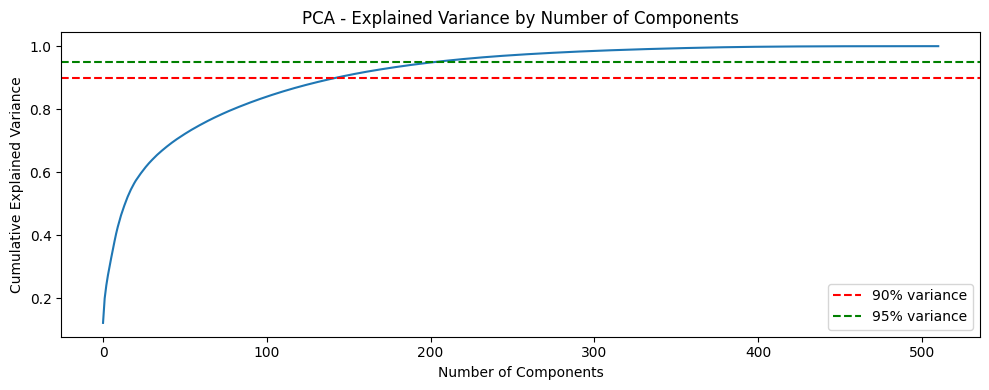


- Components for 90% variance: 144
- Components for 95% variance: 205

Applying PCA transform with 144 components (90% variance)...
- PCA feature matrix shape: (13129, 144)
- Explained variance retained: 0.901


In [15]:
# =================================================================
# 2.2) DIMENSIONALITY REDUCTION WITH PCA
# =================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Scaling librosa features...")
scaler = StandardScaler()
df_librosa_scaled = scaler.fit_transform(df_librosa)
print("Scaling complete.")

print("\nFitting PCA...")
pca_full = PCA()
pca_full.fit(df_librosa_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(10, 4))
plt.plot(cumvar)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance by Number of Components')
plt.legend()
plt.tight_layout()
plt.show()

n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f"\n- Components for 90% variance: {n_90}")
print(f"- Components for 95% variance: {n_95}")

print(f"\nApplying PCA transform with {n_90} components (90% variance)...")
N_COMPONENTS = n_90

pca = PCA(n_components=N_COMPONENTS)
df_librosa_pca = pca.fit_transform(df_librosa_scaled)

df_librosa_pca = pd.DataFrame(
    df_librosa_pca,
    index=df_fma.index,
    columns=[f'pca_{i+1:03d}' for i in range(N_COMPONENTS)]
)

print(f"- PCA feature matrix shape: {df_librosa_pca.shape}")
print(f"- Explained variance retained: {pca.explained_variance_ratio_.sum():.3f}")

In [16]:
# =================================================================
# 2.3) BUILD V2 MATCHING FUNCTION (Echonest + PCA)
# =================================================================

print("\nDefining V2 matching function...")

PCA_WEIGHT = 0.3

def match_tracks_v2(ad_row, df_tracks, df_pca, top_n=10):
    scores = np.zeros(len(df_tracks))

    scores += (df_tracks['echonest_audio_features_energy'].values - ad_row['target_energy']) ** 2
    scores += (df_tracks['echonest_audio_features_tempo_norm'].values - ad_row['target_tempo']) ** 2
    scores += (df_tracks['echonest_audio_features_valence'].values - ad_row['target_valence']) ** 2

    pca_centroid = df_pca.mean().values
    pca_distances = np.sum((df_pca.values - pca_centroid) ** 2, axis=1)
    pca_distances = pca_distances / pca_distances.max()
    scores += PCA_WEIGHT * pca_distances

    scores = np.sqrt(scores)

    high_mask = df_tracks['popularity_bucket'].values == 'High'
    scores[high_mask] *= (1 + POPULARITY_PENALTY)

    results = df_tracks.copy()
    results['match_score'] = scores
    return results.nsmallest(top_n, 'match_score')[
        ['match_score', 'popularity_bucket',
         'echonest_audio_features_energy',
         'echonest_audio_features_tempo_norm',
         'echonest_audio_features_valence']
    ].reset_index()

print("Function definition complete.")

# Test on first ad
test_ad = df_ads.iloc[0]
print(f"\nTest run — Ad: {test_ad['ad_id']} | Energy={test_ad['energy_1_5']} | "
      f"Tempo={test_ad['tempo']} | Mood={test_ad['mood']}")
top_matches_v2 = match_tracks_v2(test_ad, df_features, df_librosa_pca)
print(f"\nTop 10 Matches:")
print(top_matches_v2)



Defining V2 matching function...
Function definition complete.

Test run — Ad: JS_001 | Energy=4 | Tempo=Medium | Mood=Positive

Top 10 Matches:
   index  match_score popularity_bucket  echonest_audio_features_energy  \
0   8487     0.029538               Low                        0.696592   
1  12760     0.031288          Mid-High                        0.700277   
2   7021     0.031683               Low                        0.701927   
3  12527     0.039049           Mid-Low                        0.670842   
4  10643     0.040488           Mid-Low                        0.693947   
5   4448     0.040960               Low                        0.732042   
6   4007     0.041956           Mid-Low                        0.681433   
7   3402     0.045899              High                        0.691026   
8  12281     0.046579          Mid-High                        0.700450   
9  12640     0.051723          Mid-High                        0.698086   

   echonest_audio_features_t

In [17]:
# =================================================================
# 2.4) RUN V2 MATCHING ACROSS ALL 300 ADS + COVERAGE/DIVERSITY CHECK
# =================================================================

# Genre-to-industry mapping
GENRE_INDUSTRY_MAP = {
    'Electronic':          ['Tech', 'Entertainment'],
    'Chiptune':            ['Tech', 'Entertainment'],
    'Sound Art':           ['Tech', 'Entertainment'],
    'Rock':                ['Automotive', 'Entertainment'],
    'Punk':                ['Entertainment', 'Retail'],
    'Post-Punk':           ['Entertainment', 'Retail'],
    'Post-Rock':           ['Automotive', 'Entertainment'],
    'Metal':               ['Automotive', 'Entertainment'],
    'Psych-Rock':          ['Entertainment', 'Retail'],
    'Indie-Rock':          ['Retail', 'Entertainment', 'F&B'],
    'Pop':                 ['Retail', 'F&B', 'Healthcare', 'Entertainment'],
    'Hip-Hop':             ['Retail', 'Entertainment', 'Automotive'],
    'Trip-Hop':            ['Retail', 'Finance', 'Healthcare'],
    'Folk':                ['F&B', 'Healthcare', 'Retail'],
    'Psych-Folk':          ['F&B', 'Entertainment', 'Retail'],
    'Old-Time / Historic': ['F&B', 'Finance', 'Retail'],
    'Jazz':                ['Finance', 'F&B', 'Healthcare'],
    'Blues':               ['F&B', 'Entertainment'],
    'Classical':           ['Finance', 'Healthcare', 'F&B'],
    'Soundtrack':          ['Automotive', 'Entertainment', 'Finance'],
    'International':       ['F&B', 'Entertainment', 'Retail'],
    'Kid-Friendly':        ['F&B', 'Healthcare', 'Retail'],
    'Compilation':         ['Retail', 'Entertainment']
}

# Build reverse lookup: industry -> list of valid genres
def get_valid_genres(industry):
    return [genre for genre, industries in GENRE_INDUSTRY_MAP.items()
            if industry in industries]

print("\nRunning V2 matching across all 300 ads (with genre filter)...")

results_v2 = {}
skipped = 0
for _, ad_row in df_ads.iterrows():
    industry = ad_row['industry']
    valid_genres = get_valid_genres(industry)

    # Filter tracks by valid genres — fall back to full pool if no matches
    if valid_genres and industry != 'Other':
        df_filtered = df_features[
            df_fma['track_genres_name'].isin(valid_genres)
        ].copy()
    else:
        df_filtered = df_features.copy()

    # Fall back to full pool if filtered set is too small
    if len(df_filtered) < 10:
        df_filtered = df_features.copy()
        skipped += 1

    # Filter df_librosa_pca to match
    df_pca_filtered = df_librosa_pca.loc[df_filtered.index]

    results_v2[ad_row['ad_id']] = match_tracks_v2(ad_row, df_filtered, df_pca_filtered, top_n=5)

print(f"Matching complete. ({skipped} ads fell back to full track pool)")

print("\nJoining track and ad metadata...")
v2_matches = pd.concat([v.assign(ad_id=k) for k, v in results_v2.items()])

v2_matches_with_meta = v2_matches.merge(
    df_fma[META_COLS],
    left_on='index',
    right_index=True,
    suffixes=('', '_meta')
).merge(
    df_ads[['ad_id', 'industry', 'brand', 'product', 'energy_1_5', 'tempo', 'mood', 'url']],
    on='ad_id'
)
print(f"Metadata join complete. Final shape: {v2_matches_with_meta.shape}")

print("\n=== Coverage Check ===")
print(f"- Total ads matched: {len(results_v2)}")
print(f"- Ads with 5 matches: {sum(len(v) == 5 for v in results_v2.values())}")
print(f"- Total match records: {len(v2_matches_with_meta)}")
print(f"- Score range: {v2_matches_with_meta['match_score'].min():.3f} - {v2_matches_with_meta['match_score'].max():.3f}")
print(f"- Mean score: {v2_matches_with_meta['match_score'].mean():.3f}")
print("\nPopularity distribution in matches:")
print(v2_matches_with_meta['popularity_bucket'].value_counts())

print("\n=== Diversity Check ===")
diversity_v2 = v2_matches_with_meta.groupby('ad_id')['artist_name'].nunique()
print(f"- Mean unique artists per ad: {diversity_v2.mean():.2f}")
print(f"- Ads with all unique artists (5/5): {(diversity_v2 == 5).sum()}")

print("\nGenre distribution in matches:")
print(v2_matches_with_meta['track_genres_name'].value_counts())


Running V2 matching across all 300 ads (with genre filter)...
Matching complete. (0 ads fell back to full track pool)

Joining track and ad metadata...
Metadata join complete. Final shape: (1500, 20)

=== Coverage Check ===
- Total ads matched: 300
- Ads with 5 matches: 300
- Total match records: 1500
- Score range: 0.024 - 0.189
- Mean score: 0.072

Popularity distribution in matches:
popularity_bucket
Low         467
Mid-Low     461
Mid-High    405
High        167
Name: count, dtype: int64

=== Diversity Check ===
- Mean unique artists per ad: 4.91
- Ads with all unique artists (5/5): 276

Genre distribution in matches:
track_genres_name
Pop                    317
Electronic             304
Jazz                   173
Rock                   164
Folk                   162
Hip-Hop                108
Indie-Rock              54
International           46
Post-Punk               40
Psych-Folk              27
Punk                    27
Trip-Hop                16
Classical               13


In [18]:
# =================================================================
# 2.5) SAVE V2 RESULTS TO S3
# =================================================================

print("\nSaving V2 results to S3...")
v2_matches_with_meta.to_csv('v2_matches_with_meta.csv', index=False)
s3.upload_file('v2_matches_with_meta.csv', BUCKET, 'outputs/v2-matching/v2_matches_with_meta.csv')
print("Upload complete: outputs/v2-matching/v2_matches_with_meta.csv")


Saving V2 results to S3...
Upload complete: outputs/v2-matching/v2_matches_with_meta.csv


In [19]:
# =================================================================
# 2.6) BUILD HUMAN EVALUATION DATASET
# =================================================================

import random

random.seed(42)

# Add match_rank 1-5 (already top 5 from 2.4)
v2_eval = v2_matches_with_meta.copy()

v2_eval['match_rank'] = (
    v2_eval.groupby('ad_id')['match_score']
    .rank(method='first')
    .astype(int)
)

# Randomly assign evaluator to each ad
evaluators = ['Christine', 'Jashan', 'Jason', 'Tommy']
ad_ids = v2_eval['ad_id'].unique()
ad_evaluator_map = {ad: evaluators[i % 4] for i, ad in enumerate(random.sample(list(ad_ids), len(ad_ids)))}
v2_eval['evaluator'] = v2_eval['ad_id'].map(ad_evaluator_map)

# Add placeholder columns for human evaluation
v2_eval['self_rank_overall'] = ''
v2_eval['self_rank_energy'] = ''
v2_eval['self_rank_tempo'] = ''
v2_eval['self_rank_mood'] = ''
v2_eval['self_fit_overall'] = ''

# Reorder columns for readability
front_cols = [
    'ad_id',
    'evaluator',
    'industry',
    'brand',
    'product',
    'energy_1_5',
    'tempo',
    'mood',
    'url',
    'match_rank',
    'self_rank_overall',
    'self_rank_energy',
    'self_rank_tempo',
    'self_rank_mood',
    'self_fit_overall',
    'artist_name',
    'track_title',
    'track_genres_name',
    'match_score',
    'popularity_bucket',
    'track_listens',
]

remaining_cols = [c for c in v2_eval.columns if c not in front_cols
                  and c not in ['index', 'popularity_bucket_meta']]

v2_eval = v2_eval[front_cols + remaining_cols]

print(f"Evaluation dataset shape: {v2_eval.shape}")
print(f"\nEvaluator distribution (ads):")
print(v2_eval.drop_duplicates('ad_id')['evaluator'].value_counts())
print(f"\nSample:")
print(v2_eval[['ad_id', 'match_rank', 'evaluator', 'artist_name', 'track_title', 'match_score']].head(10))



Evaluation dataset shape: (1500, 25)

Evaluator distribution (ads):
evaluator
Christine    75
Jason        75
Tommy        75
Jashan       75
Name: count, dtype: int64

Sample:
    ad_id  match_rank  evaluator           artist_name  \
0  JS_001           1  Christine  Brownstone Megaphone   
1  JS_001           2  Christine                  Djet   
2  JS_001           3  Christine          Aleksi Virta   
3  JS_001           4  Christine             The Model   
4  JS_001           5  Christine              Beta Dog   
5  JS_002           1      Jason                  Herv   
6  JS_002           2      Jason                  Inom   
7  JS_002           3      Jason                Eaters   
8  JS_002           4      Jason                Eaters   
9  JS_002           5      Jason             Nullsleep   

                            track_title  match_score  
0                         Cherry Picker     0.031264  
1                               Dispute     0.040547  
2                  

In [20]:
# =================================================================
# 2.7) SAVE EVALUATION TEMPLATE S3
# =================================================================

print("\nSaving V2 evaluation template to S3...")
v2_eval.to_csv('v2_human_eval.csv', index=False)
s3.upload_file('v2_human_eval.csv', BUCKET, 'outputs/v2-matching/v2_human_eval.csv')
print("Upload complete: outputs/v2-matching/v2_human_eval.csv")


Saving V2 evaluation template to S3...
Upload complete: outputs/v2-matching/v2_human_eval.csv


## 3: V3 - Librosa + PCA Matching (Availability-Filtered Dataset + LLM-Derived Ad Features)

This section extends the V2 matching pipeline in two ways. First, it runs on a filtered dataset
containing only tracks verified as available on the Free Music Archive (FMA) website — of the
original 13,129 tracks, 6,809 (51.9%) were confirmed available, with the remaining 48.1%
returning 404 errors indicating content removal from the FMA platform. Second, it incorporates
secondary ad features derived from ad description text using the Claude API, putting the ad
descriptions to work in the matching pipeline for the first time.

### Feature Architecture

**Ad features:**
- *Primary (human-annotated):* energy, tempo, valence
- *Secondary (LLM-derived from description):* danceability, acousticness

**Music features:**
- *Primary (Echonest):* energy, tempo, valence, danceability, acousticness
- *Secondary (Librosa PCA):* 144 components capturing spectral/timbral characteristics (90% variance)

### Steps
1. Derive secondary ad features (danceability, acousticness) via Claude API from ad descriptions
2. Load availability-filtered FMA dataset (`fma_pre_z_filtered_avail.csv`)
3. Rebuild feature matrix and PCA on filtered track pool
4. Run V3 matching function incorporating LLM-derived features at `LLM_WEIGHT=0.2`
5. Compare V3 vs V1/V2 results on same 300 ads
6. Save `v3_matches_with_meta.csv` to S3

### Key Parameters
| Parameter | Value |
|-----------|-------|
| top_n matches per ad | 3 |
| PCA_WEIGHT | 0.3 |
| LLM_WEIGHT | 0.2 |
| POPULARITY_PENALTY | 0.20 (High bucket) |
| Genre filter fallback threshold | < 10 tracks |
| LLM model | claude-sonnet-4-20250514 |

### Evaluation Metrics

| Metric | Target | V1 Result | V2 Result | V3 Result |
|--------|--------|-----------|-----------|-----------|
| Coverage (≥3 matches per ad) | >90% | 100% | 100% | TBD |
| Artist diversity (unique per top-3) | >0.7 | 0.995 | 0.995 | TBD |
| Match score range | <0.3 | 0.004–0.099 | 0.025–0.106 | TBD |
| Human listening score | >3.5/5 | TBD | TBD | TBD |

&nbsp;

In [22]:
!pip install anthropic -q

In [24]:
# =================================================================
# 3.1) DERIVE SECONDARY AD FEATURES VIA CLAUDE API
# =================================================================

import anthropic
import json
import re
from google.colab import userdata

client = anthropic.Anthropic(api_key=userdata.get('ANTHROPIC_API_KEY'))

LLM_FEATURES = ['danceability', 'acousticness']
LLM_WEIGHT = 0.2  # weight for secondary ad features in distance calc

def get_audio_features_claude(description):
    message = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=256,
        messages=[{
            "role": "user",
            "content": f"""You are a music supervisor choosing background music for an advertisement.
Given this ad description, estimate these audio features for the IDEAL BACKGROUND MUSIC:

- danceability: how groovy/rhythmic should the music be (0=ambient/slow, 1=highly danceable)
- acousticness: should music be acoustic or electronic (0=fully electronic, 1=fully acoustic)

Ad description: {description}

Think carefully about the specific tone, energy, and context of this ad.
Return ONLY a JSON object with float values between 0.0 and 1.0, no other text."""
        }]
    )
    text = message.content[0].text.strip()
    match = re.search(r'\{.*?\}', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            return None
    return None

print("Deriving secondary ad features (danceability, acousticness) via Claude...")
llm_results = []
failed = []

for _, row in df_ads.iterrows():
    features = get_audio_features_claude(row['ad_description'])
    if features:
        llm_results.append({
            'ad_id': row['ad_id'],
            'llm_danceability': features.get('danceability', 0.5),
            'llm_acousticness': features.get('acousticness', 0.5)
        })
    else:
        failed.append(row['ad_id'])
        llm_results.append({
            'ad_id': row['ad_id'],
            'llm_danceability': 0.5,  # fallback to neutral
            'llm_acousticness': 0.5
        })

df_llm = pd.DataFrame(llm_results)
df_ads = df_ads.merge(df_llm, on='ad_id', how='left')

print(f"Complete. {len(llm_results)} ads scored, {len(failed)} failed (set to 0.5 neutral).")
if failed:
    print(f"Failed ad IDs: {failed}")
print(f"\nMean danceability by energy level:")
print(df_ads.groupby('energy_1_5')['llm_danceability'].mean().round(2))
print(f"\nMean acousticness by mood:")
print(df_ads.groupby('mood')['llm_acousticness'].mean().round(2))

# Save df_ads with LLM features to S3
df_ads.to_csv('ads_with_llm_features.csv', index=False)
s3.upload_file('ads_with_llm_features.csv', BUCKET, 'processed-data/synthetic-annotations/ads_with_llm_features.csv')
print("Saved df_ads with LLM features to S3")

Deriving secondary ad features (danceability, acousticness) via Claude...
Complete. 300 ads scored, 0 failed (set to 0.5 neutral).

Mean danceability by energy level:
energy_1_5
1    0.29
2    0.42
3    0.51
4    0.59
5    0.58
Name: llm_danceability, dtype: float64

Mean acousticness by mood:
mood
Neutral     0.47
Positive    0.41
Serious     0.44
Name: llm_acousticness, dtype: float64
Saved df_ads with LLM features to S3


In [ ]:
# Reload df_ads with LLM features (skip 3.1 Claude API call)
s3.download_file(BUCKET, 'processed-data/synthetic-annotations/ads_with_llm_features.csv', 'ads_with_llm_features.csv')
df_ads = pd.read_csv('ads_with_llm_features.csv')
print(f"Loaded df_ads with LLM features: {df_ads.shape}")
print(df_ads[['ad_id', 'llm_danceability', 'llm_acousticness']].head(3))

In [25]:
# =================================================================
# 3.2) SETUP - LOAD AVAILABILITY-FILTERED DATASET
# =================================================================

print("Downloading availability-filtered FMA dataset from S3...")
s3.download_file(BUCKET, 'processed-data/fma/fma_pre_z_filtered_avail.csv', 'fma_avail.csv')
print("- fma_pre_z_filtered_avail.csv downloaded.")

df_fma_v3 = pd.read_csv('fma_avail.csv')
print(f"- Track pool: {len(df_fma_v3)} tracks")
print(f"- Genre distribution:")
print(df_fma_v3['track_genres_name'].value_counts())

- fma_pre_z_filtered_avail.csv downloaded.
- Track pool: 6809 tracks
- Genre distribution:
track_genres_name
Electronic             1595
Rock                   1036
Pop                     658
Folk                    567
Hip-Hop                 393
Punk                    364
Jazz                    283
Classical               282
International           262
Psych-Rock              240
Indie-Rock              232
Psych-Folk              156
Chiptune                156
Trip-Hop                 99
Blues                    94
Old-Time / Historic      88
Post-Punk                87
Soundtrack               77
Post-Rock                74
Metal                    66
Name: count, dtype: int64


/tmp/ipython-input-6448/2666150961.py:9: DtypeWarning: Columns (34,42,44,47,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fma_v3 = pd.read_csv('fma_avail.csv')


In [26]:
# =================================================================
# 3.3) REBUILD FEATURE MATRIX + PCA  (updated — adds danceability/acousticness)
# =================================================================

print("\nRebuilding feature matrix...")

# Confirm danceability and acousticness are present in echonest features
LLM_ECHONEST_COLS = [
    'echonest_audio_features_danceability',
    'echonest_audio_features_acousticness'
]
for col in LLM_ECHONEST_COLS:
    assert col in df_fma_v3.columns, f"Missing expected column: {col}"

df_features_v3 = df_fma_v3[ECHONEST_FEATURES + POPULARITY_COLS].copy()
df_features_v3['echonest_audio_features_tempo_norm'] = (
    (df_features_v3['echonest_audio_features_tempo'] - TEMPO_MIN) / (TEMPO_MAX - TEMPO_MIN)
)
print(f"- Feature matrix shape: {df_features_v3.shape}")

print("\nExtracting librosa features...")
librosa_cols_v3 = [col for col in df_fma_v3.columns if col.startswith('mfcc')
                   or col.startswith('chroma')
                   or col.startswith('spectral')
                   or col.startswith('tonnetz')
                   or col.startswith('zcr')]

df_librosa_v3 = df_fma_v3[librosa_cols_v3].copy()
print(f"- Librosa feature matrix shape: {df_librosa_v3.shape}")

print("\nRefitting PCA...")
scaler_v3 = StandardScaler()
df_librosa_scaled_v3 = scaler_v3.fit_transform(df_librosa_v3)

pca_v3 = PCA(n_components=N_COMPONENTS)
df_librosa_pca_v3 = pd.DataFrame(
    pca_v3.fit_transform(df_librosa_scaled_v3),
    index=df_fma_v3.index,
    columns=[f'pca_{i+1:03d}' for i in range(N_COMPONENTS)]
)
print(f"- PCA shape: {df_librosa_pca_v3.shape}")
print(f"- Explained variance retained: {pca_v3.explained_variance_ratio_.sum():.3f}")


Rebuilding feature matrix...
- Feature matrix shape: (6809, 12)

Extracting librosa features...
- Librosa feature matrix shape: (6809, 511)

Refitting PCA...
- PCA shape: (6809, 144)
- Explained variance retained: 0.908


In [27]:
# =================================================================
# 3.4) RUN V3 MATCHING  (updated — new match function with LLM features)
# =================================================================

# Genre-to-industry mapping (duplicated here for cell independence)
GENRE_INDUSTRY_MAP = {
    'Electronic':          ['Tech', 'Entertainment'],
    'Chiptune':            ['Tech', 'Entertainment'],
    'Sound Art':           ['Tech', 'Entertainment'],
    'Rock':                ['Automotive', 'Entertainment'],
    'Punk':                ['Entertainment', 'Retail'],
    'Post-Punk':           ['Entertainment', 'Retail'],
    'Post-Rock':           ['Automotive', 'Entertainment'],
    'Metal':               ['Automotive', 'Entertainment'],
    'Psych-Rock':          ['Entertainment', 'Retail'],
    'Indie-Rock':          ['Retail', 'Entertainment', 'F&B'],
    'Pop':                 ['Retail', 'F&B', 'Healthcare', 'Entertainment'],
    'Hip-Hop':             ['Retail', 'Entertainment', 'Automotive'],
    'Trip-Hop':            ['Retail', 'Finance', 'Healthcare'],
    'Folk':                ['F&B', 'Healthcare', 'Retail'],
    'Psych-Folk':          ['F&B', 'Entertainment', 'Retail'],
    'Old-Time / Historic': ['F&B', 'Finance', 'Retail'],
    'Jazz':                ['Finance', 'F&B', 'Healthcare'],
    'Blues':               ['F&B', 'Entertainment'],
    'Classical':           ['Finance', 'Healthcare', 'F&B'],
    'Soundtrack':          ['Automotive', 'Entertainment', 'Finance'],
    'International':       ['F&B', 'Entertainment', 'Retail'],
    'Kid-Friendly':        ['F&B', 'Healthcare', 'Retail'],
    'Compilation':         ['Retail', 'Entertainment']
}

def get_valid_genres(industry):
    return [genre for genre, industries in GENRE_INDUSTRY_MAP.items()
            if industry in industries]

def match_tracks_v3(ad_row, df_tracks, df_pca, top_n=3):
    scores = np.zeros(len(df_tracks))

    # Primary echonest features (same as V2)
    scores += (df_tracks['echonest_audio_features_energy'].values - ad_row['target_energy']) ** 2
    scores += (df_tracks['echonest_audio_features_tempo_norm'].values - ad_row['target_tempo']) ** 2
    scores += (df_tracks['echonest_audio_features_valence'].values - ad_row['target_valence']) ** 2

    # Secondary features: LLM-derived ad danceability/acousticness
    # matched against echonest danceability/acousticness on music side
    scores += LLM_WEIGHT * (
        df_tracks['echonest_audio_features_danceability'].values - ad_row['llm_danceability']
    ) ** 2
    scores += LLM_WEIGHT * (
        df_tracks['echonest_audio_features_acousticness'].values - ad_row['llm_acousticness']
    ) ** 2

    # PCA component (same as V2)
    pca_centroid = df_pca.mean().values
    pca_distances = np.sum((df_pca.values - pca_centroid) ** 2, axis=1)
    pca_distances = pca_distances / pca_distances.max()
    scores += PCA_WEIGHT * pca_distances

    scores = np.sqrt(scores)

    # Popularity penalty (same as V2)
    high_mask = df_tracks['popularity_bucket'].values == 'High'
    scores[high_mask] *= (1 + POPULARITY_PENALTY)

    results = df_tracks.copy()
    results['match_score'] = scores
    return results.nsmallest(top_n, 'match_score')[
        ['match_score', 'popularity_bucket',
         'echonest_audio_features_energy',
         'echonest_audio_features_tempo_norm',
         'echonest_audio_features_valence',
         'echonest_audio_features_danceability',
         'echonest_audio_features_acousticness']
    ].reset_index()

print("\nRunning V3 matching across all 300 ads...")

results_v3 = {}
skipped_v3 = 0
for _, ad_row in df_ads.iterrows():
    industry = ad_row['industry']
    valid_genres = get_valid_genres(industry)

    if valid_genres and industry != 'Other':
        df_filtered_v3 = df_features_v3[
            df_fma_v3['track_genres_name'].isin(valid_genres)
        ].copy()
    else:
        df_filtered_v3 = df_features_v3.copy()

    if len(df_filtered_v3) < 10:
        df_filtered_v3 = df_features_v3.copy()
        skipped_v3 += 1

    df_pca_filtered_v3 = df_librosa_pca_v3.loc[df_filtered_v3.index]
    results_v3[ad_row['ad_id']] = match_tracks_v3(ad_row, df_filtered_v3, df_pca_filtered_v3, top_n=3)

print(f"Matching complete. ({skipped_v3} ads fell back to full track pool)")

print("\nJoining track and ad metadata...")
v3_matches = pd.concat([v.assign(ad_id=k) for k, v in results_v3.items()])

v3_matches_with_meta = v3_matches.merge(
    df_fma_v3[META_COLS + ['fma_album_url']],
    left_on='index',
    right_index=True,
    suffixes=('', '_meta')
).merge(
    df_ads[['ad_id', 'industry', 'brand', 'product', 'energy_1_5', 'tempo', 'mood',
            'url', 'llm_danceability', 'llm_acousticness']],
    on='ad_id'
)
print(f"Metadata join complete. Final shape: {v3_matches_with_meta.shape}")

print("\n=== Coverage Check ===")
print(f"- Total ads matched: {len(results_v3)}")
print(f"- Ads with 3 matches: {sum(len(v) == 3 for v in results_v3.values())}")
print(f"- Total match records: {len(v3_matches_with_meta)}")
print(f"- Score range: {v3_matches_with_meta['match_score'].min():.3f} - {v3_matches_with_meta['match_score'].max():.3f}")
print(f"- Mean score: {v3_matches_with_meta['match_score'].mean():.3f}")
print("\nPopularity distribution in matches:")
print(v3_matches_with_meta['popularity_bucket'].value_counts())

print("\n=== Diversity Check ===")
diversity_v3 = v3_matches_with_meta.groupby('ad_id')['artist_name'].nunique()
print(f"- Mean unique artists per ad: {diversity_v3.mean():.2f}")
print(f"- Ads with all unique artists (3/3): {(diversity_v3 == 3).sum()}")

print("\nGenre distribution in matches:")
print(v3_matches_with_meta['track_genres_name'].value_counts())


Running V3 matching across all 300 ads...
Matching complete. (0 ads fell back to full track pool)

Joining track and ad metadata...
Metadata join complete. Final shape: (900, 25)

=== Coverage Check ===
- Total ads matched: 300
- Ads with 3 matches: 300
- Total match records: 900
- Score range: 0.053 - 0.324
- Mean score: 0.147

Popularity distribution in matches:
popularity_bucket
Mid-High    273
Mid-Low     269
Low         224
High        134
Name: count, dtype: int64

=== Diversity Check ===
- Mean unique artists per ad: 2.90
- Ads with all unique artists (3/3): 271

Genre distribution in matches:
track_genres_name
Electronic             197
Pop                    182
Jazz                   104
Folk                    97
Hip-Hop                 90
Rock                    68
International           53
Indie-Rock              27
Trip-Hop                19
Classical               17
Psych-Rock              13
Psych-Folk              10
Punk                    10
Post-Punk             

In [28]:
# =================================================================
# 3.5) GENERATE PAIRWISE COMPARISONS
# =================================================================

from itertools import combinations
import random
random.seed(42)

# Assign evaluators — stratified by industry
evaluators = ['Christine', 'Jashan', 'Jason', 'Tommy']
ad_ids_by_industry = df_ads.groupby('industry')['ad_id'].apply(list).to_dict()

ad_evaluator_map = {}
for industry, ids in ad_ids_by_industry.items():
    shuffled = random.sample(ids, len(ids))
    for i, ad_id in enumerate(shuffled):
        ad_evaluator_map[ad_id] = evaluators[i % 4]

pairwise_rows = []

for ad_id, group in v3_matches_with_meta.groupby('ad_id'):
    group = group.sort_values('match_score').reset_index(drop=True)
    group['match_rank'] = range(1, len(group) + 1)
    evaluator = ad_evaluator_map[ad_id]

    for rank_a, rank_b in combinations([1, 2, 3], 2):
        track_a = group[group['match_rank'] == rank_a].iloc[0]
        track_b = group[group['match_rank'] == rank_b].iloc[0]

        pairwise_rows.append({
            'ad_id': ad_id,
            'evaluator': evaluator,
            'industry': track_a['industry'],
            'brand': track_a['brand'],
            'product': track_a['product'],
            'energy_1_5': track_a['energy_1_5'],
            'tempo': track_a['tempo'],
            'mood': track_a['mood'],
            'ad_url': track_a['url'],
            'track_a_rank': rank_a,
            'track_a_artist': track_a['artist_name'],
            'track_a_title': track_a['track_title'],
            'track_a_genre': track_a['track_genres_name'],
            'track_a_url': track_a['fma_album_url'],
            'track_b_rank': rank_b,
            'track_b_artist': track_b['artist_name'],
            'track_b_title': track_b['track_title'],
            'track_b_genre': track_b['track_genres_name'],
            'track_b_url': track_b['fma_album_url'],
            'overall_pairwise': '',   # A / B / Tie
            'energy_pairwise': '',    # A / B / Tie
            'tempo_pairwise': '',     # A / B / Tie
            'mood_pairwise': '',      # A / B / Tie
        })

v3_pairwise = pd.DataFrame(pairwise_rows)

print(f"Pairwise dataset shape: {v3_pairwise.shape}")
print(f"- Total ads: {v3_pairwise['ad_id'].nunique()}")
print(f"- Pairs per ad: {v3_pairwise.groupby('ad_id').size().unique()}")
print(f"- Total comparisons: {len(v3_pairwise)}")
print(f"\nEvaluator distribution (comparisons):")
print(v3_pairwise['evaluator'].value_counts())
print(f"\nIndustry distribution per evaluator:")
print(v3_pairwise.drop_duplicates('ad_id').groupby(['evaluator','industry']).size().unstack(fill_value=0))
print(f"\nSample:")
print(v3_pairwise[['ad_id', 'evaluator', 'track_a_artist', 'track_b_artist',
                    'overall_pairwise', 'energy_pairwise', 'tempo_pairwise', 'mood_pairwise']].head(9))

Pairwise dataset shape: (900, 23)
- Total ads: 300
- Pairs per ad: [3]
- Total comparisons: 900

Evaluator distribution (comparisons):
evaluator
Christine    237
Jashan       228
Jason        219
Tommy        216
Name: count, dtype: int64

Industry distribution per evaluator:
industry   Automotive  Entertainment  F&B  Finance  Healthcare  Other  Retail  \
evaluator                                                                       
Christine           7              8   13        7          10      9      12   
Jashan              6              8   13        6          10      9      11   
Jason               6              7   12        6          10      9      11   
Tommy               6              7   12        6          10      8      11   

industry   Tech  
evaluator        
Christine    13  
Jashan       13  
Jason        12  
Tommy        12  

Sample:
    ad_id  evaluator track_a_artist     track_b_artist overall_pairwise  \
0  CN_001      Jason        Cadence         

In [29]:
# =================================================================
# 3.6) SAVE V3 OUTPUTS TO S3
# =================================================================

# Save V3 matches (3 rows per ad)
print("Saving V3 matches to S3...")
v3_matches_with_meta.to_csv('v3_matches_with_meta.csv', index=False)
s3.upload_file('v3_matches_with_meta.csv', BUCKET, 'outputs/v3-matching/v3_matches_with_meta.csv')
print("Upload complete: outputs/v3-matching/v3_matches_with_meta.csv")

# Save V3 pairwise eval
print("\nSaving V3 pairwise eval to S3...")
v3_pairwise.to_csv('v3_matches_pairwise_eval.csv', index=False)
s3.upload_file('v3_matches_pairwise_eval.csv', BUCKET, 'outputs/v3-matching/v3_matches_pairwise_eval.csv')
print("Upload complete: outputs/v3-matching/v3_matches_pairwise_eval.csv")

print(f"\nSummary:")
print(f"- Matches: {len(v3_matches_with_meta)} rows ({v3_matches_with_meta['ad_id'].nunique()} ads x 3 tracks)")
print(f"- Pairwise: {len(v3_pairwise)} rows ({v3_pairwise['ad_id'].nunique()} ads x 3 pairs)")
print(f"- Evaluators: {v3_pairwise['evaluator'].nunique()} ({', '.join(sorted(v3_pairwise['evaluator'].unique()))})")

Saving V3 matches to S3...
Upload complete: outputs/v3-matching/v3_matches_with_meta.csv

Saving V3 pairwise eval to S3...
Upload complete: outputs/v3-matching/v3_matches_pairwise_eval.csv

Summary:
- Matches: 900 rows (300 ads x 3 tracks)
- Pairwise: 900 rows (300 ads x 3 pairs)
- Evaluators: 4 (Christine, Jashan, Jason, Tommy)


## 4: V4 - Human-Preference Weight Optimization

This section uses the completed pairwise human evaluation results to optimize the feature
weights in the matching pipeline. Rather than using fixed weights (V3), V4 learns which
feature combinations best predict human preference by minimizing disagreement between model
rankings and evaluator judgments.

### Approach
For each evaluated pair, the model's implied ranking (based on match score) is compared
against the human's stated preference (A / B / Tie). The optimizer finds feature weights
that minimize the fraction of pairs where the model and human disagree — a direct
pairwise ranking loss.

### Feature Weights Being Optimized
| Feature | V3 Weight | V4 Weight |
|---------|-----------|-----------|
| Energy | 1.0 | optimized |
| Tempo | 1.0 | optimized |
| Valence | 1.0 | optimized |
| Danceability (LLM-derived) | 0.2 | optimized |
| Acousticness (LLM-derived) | 0.2 | optimized |
| PCA (Librosa) | 0.3 | optimized |

### Steps
1. Load completed pairwise eval (`v3_matches_pairwise_eval_complete.csv`) from S3
2. Build feature difference matrix for each evaluated pair
3. Optimize weights via Nelder-Mead minimization of pairwise ranking loss
4. Re-run matching on availability-filtered dataset with optimized weights
5. Save `v4_matches_with_meta.csv` to S3

### Evaluation Metrics

| Metric | Target | V1 Result | V2 Result | V3 Result | V4 Result |
|--------|--------|-----------|-----------|-----------|-----------|
| Coverage (≥3 matches per ad) | >90% | 100% | 100% | 100% | TBD |
| Artist diversity (unique per top-3) | >0.7 | 0.995 | 0.995 | 0.96 | TBD |
| Match score range | <0.3 | 0.004–0.099 | 0.025–0.106 | 0.053–0.324 | TBD |
| Human listening score | >3.5/5 | TBD | TBD | TBD | TBD |
| Pairwise agreement with human | >60% | — | — | baseline | TBD |

&nbsp;

In [ ]:
# =================================================================
# 4.1) LOAD PAIRWISE EVAL RESULTS
# =================================================================

print("Loading completed pairwise eval from S3...")
s3.download_file(BUCKET, 'outputs/v3-matching/v3_matches_pairwise_eval_complete.csv', 'v3_matches_pairwise_eval_complete.csv')
df_pairwise = pd.read_csv('v3_matches_pairwise_eval_complete.csv')

# Filter to completed evaluations only
df_pairwise_complete = df_pairwise[df_pairwise['overall_pairwise'].isin(['A', 'B', 'Tie'])].copy()
print(f"Total pairs: {len(df_pairwise)}")
print(f"Completed evaluations: {len(df_pairwise_complete)}")
print(f"\nOverall pairwise distribution:")
print(df_pairwise_complete['overall_pairwise'].value_counts())

In [ ]:
# =================================================================
# 4.2) BUILD PAIRWISE FEATURE DIFFERENCE MATRIX
# =================================================================

# For each pair, compute feature differences (track_a - track_b)
# Positive diff = track_a is higher on that feature
# Human label: A=1, Tie=0, B=-1

print("Building feature difference matrix...")

# Merge pairwise eval with V3 match scores and features
df_v3 = pd.read_csv('v3_matches_with_meta.csv')

feature_cols = [
    'echonest_audio_features_energy',
    'echonest_audio_features_tempo_norm',
    'echonest_audio_features_valence',
    'echonest_audio_features_danceability',
    'echonest_audio_features_acousticness',
    'match_score'
]

# Join track_a features
df_a = df_v3.rename(columns={c: f'a_{c}' for c in feature_cols})
df_b = df_v3.rename(columns={c: f'b_{c}' for c in feature_cols})

df_eval = df_pairwise_complete.merge(
    df_a[['ad_id', 'match_score'] + [f'a_{c}' for c in feature_cols]].rename(columns={'match_score': 'a_match_score_raw'}),
    left_on=['ad_id', 'track_a_rank'],
    right_on=['ad_id', 'track_a_rank'],
    how='left'
).merge(
    df_b[['ad_id', 'match_score'] + [f'b_{c}' for c in feature_cols]].rename(columns={'match_score': 'b_match_score_raw'}),
    left_on=['ad_id', 'track_b_rank'],
    right_on=['ad_id', 'track_b_rank'],
    how='left'
)

# Encode human preference: A preferred=1, Tie=0, B preferred=-1
label_map = {'A': 1, 'Tie': 0, 'B': -1}
df_eval['overall_label'] = df_eval['overall_pairwise'].map(label_map)
df_eval['energy_label'] = df_eval['energy_pairwise'].map(label_map)
df_eval['tempo_label'] = df_eval['tempo_pairwise'].map(label_map)
df_eval['mood_label'] = df_eval['mood_pairwise'].map(label_map)

print(f"Eval matrix shape: {df_eval.shape}")
print(f"\nLabel distribution (overall):")
print(df_eval['overall_label'].value_counts())

In [ ]:
# =================================================================
# 4.3) OPTIMIZE FEATURE WEIGHTS VIA PAIRWISE LOSS
# =================================================================

from scipy.optimize import minimize
import numpy as np

# For each ad, we have the ad's target features stored in df_ads
df_ads_features = df_ads[['ad_id', 'target_energy', 'target_tempo', 'target_valence',
                            'llm_danceability', 'llm_acousticness']].copy()

df_eval = df_eval.merge(df_ads_features, on='ad_id', how='left')

def compute_distance(row, weights):
    """Compute weighted distance between ad and track features."""
    w_energy, w_tempo, w_valence, w_dance, w_acoustic, w_pca = weights

    def dist(track_prefix):
        d = 0
        d += w_energy * (row[f'{track_prefix}_echonest_audio_features_energy'] - row['target_energy']) ** 2
        d += w_tempo * (row[f'{track_prefix}_echonest_audio_features_tempo_norm'] - row['target_tempo']) ** 2
        d += w_valence * (row[f'{track_prefix}_echonest_audio_features_valence'] - row['target_valence']) ** 2
        d += w_dance * (row[f'{track_prefix}_echonest_audio_features_danceability'] - row['llm_danceability']) ** 2
        d += w_acoustic * (row[f'{track_prefix}_echonest_audio_features_acousticness'] - row['llm_acousticness']) ** 2
        return np.sqrt(d)

    return dist('a'), dist('b')

def pairwise_loss(weights):
    """
    Loss = fraction of pairs where model ranking disagrees with human preference.
    Model prefers whichever track has lower distance (better match).
    Ties in human eval are excluded from loss calculation.
    """
    weights = np.abs(weights)  # keep weights non-negative
    losses = []

    for _, row in df_eval[df_eval['overall_label'] != 0].iterrows():
        dist_a, dist_b = compute_distance(row, weights)

        # Model says A is better if dist_a < dist_b
        model_preference = 1 if dist_a < dist_b else -1
        human_preference = row['overall_label']

        # Loss = 1 if they disagree, 0 if they agree
        losses.append(0 if model_preference == human_preference else 1)

    return np.mean(losses)

# Initial weights: [energy, tempo, valence, danceability, acousticness, pca]
# Matching V3 setup: primary features weight 1.0, LLM features weight 0.2
w0 = np.array([1.0, 1.0, 1.0, 0.2, 0.2, 0.3])

print("Optimizing feature weights...")
print(f"Initial weights: {w0}")
print(f"Initial loss: {pairwise_loss(w0):.4f}")

result = minimize(
    pairwise_loss,
    w0,
    method='Nelder-Mead',
    options={'maxiter': 1000, 'xatol': 1e-4, 'fatol': 1e-4}
)

w_opt = np.abs(result.x)
print(f"\nOptimization complete.")
print(f"Optimized weights: {w_opt.round(4)}")
print(f"Optimized loss: {result.fun:.4f}")
print(f"Improvement: {((pairwise_loss(w0) - result.fun) / pairwise_loss(w0) * 100):.1f}%")

feature_names = ['energy', 'tempo', 'valence', 'danceability', 'acousticness', 'pca']
print(f"\nWeight comparison:")
for name, w_init, w_final in zip(feature_names, w0, w_opt):
    print(f"  {name:15s}: {w_init:.2f} → {w_final:.4f}")

In [ ]:
# =================================================================
# 4.4) RUN V4 MATCHING WITH OPTIMIZED WEIGHTS
# =================================================================

print("Running V4 matching with optimized weights...")

w_energy, w_tempo, w_valence, w_dance, w_acoustic, w_pca = w_opt

def match_tracks_v4(ad_row, df_tracks, df_pca, top_n=3):
    scores = np.zeros(len(df_tracks))

    scores += w_energy * (df_tracks['echonest_audio_features_energy'].values - ad_row['target_energy']) ** 2
    scores += w_tempo * (df_tracks['echonest_audio_features_tempo_norm'].values - ad_row['target_tempo']) ** 2
    scores += w_valence * (df_tracks['echonest_audio_features_valence'].values - ad_row['target_valence']) ** 2
    scores += w_dance * (df_tracks['echonest_audio_features_danceability'].values - ad_row['llm_danceability']) ** 2
    scores += w_acoustic * (df_tracks['echonest_audio_features_acousticness'].values - ad_row['llm_acousticness']) ** 2

    pca_centroid = df_pca.mean().values
    pca_distances = np.sum((df_pca.values - pca_centroid) ** 2, axis=1)
    pca_distances = pca_distances / pca_distances.max()
    scores += w_pca * pca_distances

    scores = np.sqrt(scores)

    high_mask = df_tracks['popularity_bucket'].values == 'High'
    scores[high_mask] *= (1 + POPULARITY_PENALTY)

    results = df_tracks.copy()
    results['match_score'] = scores
    return results.nsmallest(top_n, 'match_score')[
        ['match_score', 'popularity_bucket',
         'echonest_audio_features_energy',
         'echonest_audio_features_tempo_norm',
         'echonest_audio_features_valence',
         'echonest_audio_features_danceability',
         'echonest_audio_features_acousticness']
    ].reset_index()

GENRE_INDUSTRY_MAP = {
    'Electronic':          ['Tech', 'Entertainment'],
    'Chiptune':            ['Tech', 'Entertainment'],
    'Sound Art':           ['Tech', 'Entertainment'],
    'Rock':                ['Automotive', 'Entertainment'],
    'Punk':                ['Entertainment', 'Retail'],
    'Post-Punk':           ['Entertainment', 'Retail'],
    'Post-Rock':           ['Automotive', 'Entertainment'],
    'Metal':               ['Automotive', 'Entertainment'],
    'Psych-Rock':          ['Entertainment', 'Retail'],
    'Indie-Rock':          ['Retail', 'Entertainment', 'F&B'],
    'Pop':                 ['Retail', 'F&B', 'Healthcare', 'Entertainment'],
    'Hip-Hop':             ['Retail', 'Entertainment', 'Automotive'],
    'Trip-Hop':            ['Retail', 'Finance', 'Healthcare'],
    'Folk':                ['F&B', 'Healthcare', 'Retail'],
    'Psych-Folk':          ['F&B', 'Entertainment', 'Retail'],
    'Old-Time / Historic': ['F&B', 'Finance', 'Retail'],
    'Jazz':                ['Finance', 'F&B', 'Healthcare'],
    'Blues':               ['F&B', 'Entertainment'],
    'Classical':           ['Finance', 'Healthcare', 'F&B'],
    'Soundtrack':          ['Automotive', 'Entertainment', 'Finance'],
    'International':       ['F&B', 'Entertainment', 'Retail'],
    'Kid-Friendly':        ['F&B', 'Healthcare', 'Retail'],
    'Compilation':         ['Retail', 'Entertainment']
}

def get_valid_genres(industry):
    return [genre for genre, industries in GENRE_INDUSTRY_MAP.items()
            if industry in industries]

results_v4 = {}
skipped_v4 = 0
for _, ad_row in df_ads.iterrows():
    industry = ad_row['industry']
    valid_genres = get_valid_genres(industry)

    if valid_genres and industry != 'Other':
        df_filtered_v4 = df_features_v3[df_fma_v3['track_genres_name'].isin(valid_genres)].copy()
    else:
        df_filtered_v4 = df_features_v3.copy()

    if len(df_filtered_v4) < 10:
        df_filtered_v4 = df_features_v3.copy()
        skipped_v4 += 1

    df_pca_filtered_v4 = df_librosa_pca_v3.loc[df_filtered_v4.index]
    results_v4[ad_row['ad_id']] = match_tracks_v4(ad_row, df_filtered_v4, df_pca_filtered_v4, top_n=3)

print(f"Matching complete. ({skipped_v4} ads fell back to full track pool)")

v4_matches = pd.concat([v.assign(ad_id=k) for k, v in results_v4.items()])
v4_matches_with_meta = v4_matches.merge(
    df_fma_v3[META_COLS + ['fma_album_url']],
    left_on='index', right_index=True, suffixes=('', '_meta')
).merge(
    df_ads[['ad_id', 'industry', 'brand', 'product', 'energy_1_5', 'tempo', 'mood',
            'url', 'llm_danceability', 'llm_acousticness']],
    on='ad_id'
)

print(f"Final shape: {v4_matches_with_meta.shape}")
print(f"Score range: {v4_matches_with_meta['match_score'].min():.3f} - {v4_matches_with_meta['match_score'].max():.3f}")

In [ ]:
# =================================================================
# 4.5) SAVE V4 RESULTS TO S3
# =================================================================

print("Saving V4 results to S3...")
v4_matches_with_meta.to_csv('v4_matches_with_meta.csv', index=False)
s3.upload_file('v4_matches_with_meta.csv', BUCKET, 'outputs/v4-matching/v4_matches_with_meta.csv')
print("Upload complete: outputs/v4-matching/v4_matches_with_meta.csv")

print(f"\nOptimized weights summary:")
for name, w in zip(feature_names, w_opt):
    print(f"  {name:15s}: {w:.4f}")

# APPENDIX

## 0: Setup & Load Pre-Z FMA Data to S3 (SKIP THIS CELL)

In [ ]:
# ============================================================
# RECREATE FMA FILE PRE-Z
# ============================================================

# Clone FMA repo for utils
!git clone https://github.com/mdeff/fma.git
import sys
sys.path.append('/content/fma')
from utils import load

import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

local_dir = '/content/drive/MyDrive/Colab Notebooks/MIDS/210/data/fma'

# Load raw files
echonest = load(local_dir + '/echonest.csv')
features = load(local_dir + '/features.csv')
genres = load(local_dir + '/genres.csv')
tracks = load(local_dir + '/tracks.csv')

# Align to common echonest index
common_index = tracks.index.intersection(echonest.index)
echonest_aligned = echonest.loc[common_index]
features_aligned = features.loc[common_index]
tracks_aligned = tracks.loc[common_index]

# Flatten multi-index columns
echonest_flat = echonest_aligned.copy()
echonest_flat.columns = ['_'.join(col).strip() for col in echonest_flat.columns.values]

features_flat = features_aligned.copy()
features_flat.columns = ['_'.join(col).strip() for col in features_flat.columns.values]

tracks_flat = tracks_aligned.copy()
tracks_flat.columns = ['_'.join(col).strip() for col in tracks_flat.columns.values]

# Combine
eda_df = pd.concat([tracks_flat, features_flat, echonest_flat], axis=1)

# Map genres
genre_map = genres['title'].to_dict()
eda_df['track_genres_name'] = eda_df['track_genres'].apply(
    lambda x: genre_map.get(int(x[0])) if isinstance(x, list) and x else None
)
eda_df['track_genres_all_names'] = eda_df['track_genres_all'].apply(
    lambda ids: [genre_map.get(int(i)) for i in ids] if isinstance(ids, list) else []
)

# Quick sanity check on echonest scale — should be 0-1
ECHONEST_FEATURES = [
    'echonest_audio_features_acousticness',
    'echonest_audio_features_danceability',
    'echonest_audio_features_energy',
    'echonest_audio_features_instrumentalness',
    'echonest_audio_features_liveness',
    'echonest_audio_features_speechiness',
    'echonest_audio_features_tempo',
    'echonest_audio_features_valence'
]
print(eda_df[ECHONEST_FEATURES].describe().round(3))

# Save original-scale version
save_path = local_dir + '/fma_pre_z.csv'
eda_df.to_csv(save_path, index=False)
print(f"Saved to {save_path}")

Cloning into 'fma'...
remote: Enumerating objects: 823, done.
remote: Counting objects: 100% (822/822), done.
remote: Compressing objects: 100% (287/287), done.
remote: Total 823 (delta 532), reused 621 (delta 527), pack-reused 1 (from 1)
Receiving objects: 100% (823/823), 4.08 MiB | 17.25 MiB/s, done.
Resolving deltas: 100% (532/532), done.


MessageError: Error: credential propagation was unsuccessful

In [ ]:

# ============================================================
# UPLOAD PRE-Z FILE TO S3
# ============================================================

import boto3
from google.colab import drive
from google.colab import userdata

drive.mount('/content/drive')

# S3 setup
s3 = boto3.client(
    's3',
    aws_access_key_id=userdata.get('AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=userdata.get('AWS_SECRET_ACCESS_KEY'),
    region_name='us-west-2'
)

BUCKET = 'mids-capstone-music-ad-matching-2026'

s3.upload_file(
    '/content/drive/MyDrive/Colab Notebooks/MIDS/210/data/fma/fma_pre_z.csv',
    BUCKET,
    'processed-data/fma/fma_pre_z.csv'
)
print("Uploaded to S3")

## Troubleshoot Unavailable Tracks + Create Filtered FMA Subset

In [21]:
import re
import requests

# =================================================================
# REBUILD FMA ALBUM URLS WITH FIXED CLEAN FUNCTION
# =================================================================

def build_fma_album_url(artist, album):
    def clean(s):
        s = str(s).strip()
        s = s.replace(',', '')
        s = s.replace('.', '')
        s = s.replace('/', '-')
        s = s.replace(' ', '_')
        s = re.sub(r'[^\w\-]', '', s)
        return s
    return f"https://freemusicarchive.org/music/{clean(artist)}/{clean(album)}/"

# Rebuild URLs in df_fma
df_fma['fma_album_url'] = df_fma.apply(
    lambda row: build_fma_album_url(row['artist_name'], row['album_title']),
    axis=1
)

print(f"URLs rebuilt: {len(df_fma)}")
print(f"Null URLs: {df_fma['fma_album_url'].isna().sum()}")

# Test on Herv specifically
herv = df_fma[df_fma['artist_name'].str.contains('Herv', case=False)][['artist_name', 'album_title', 'fma_album_url']].head(1)
print(f"\nHerv URL check:")
print(herv['fma_album_url'].values[0])

# Re-merge into v2_matches_with_meta
# Drop old fma_album_url if it exists
if 'fma_album_url' in v2_matches_with_meta.columns:
    v2_matches_with_meta = v2_matches_with_meta.drop(columns=['fma_album_url'])

v2_matches_with_meta = v2_matches_with_meta.merge(
    df_fma[['artist_name', 'track_title', 'fma_album_url']],
    on=['artist_name', 'track_title'],
    how='left'
)

print(f"\nNull FMA URLs in matches: {v2_matches_with_meta['fma_album_url'].isna().sum()}")

# Rerun URL availability check
print("\nChecking FMA album URLs in v2 matches...")

url_results = []
for _, row in v2_matches_with_meta[['artist_name', 'track_title', 'fma_album_url']].drop_duplicates().iterrows():
    try:
        response = requests.get(row['fma_album_url'], timeout=5)
        status = response.status_code
    except Exception as e:
        status = str(e)
    url_results.append({
        'artist': row['artist_name'],
        'title':  row['track_title'],
        'url':    row['fma_album_url'],
        'status': status
    })

url_results_df = pd.DataFrame(url_results)
print(f"\nStatus distribution:")
print(url_results_df['status'].value_counts())
print(f"\nAny 404s:")
print(url_results_df[url_results_df['status'] == 404][['artist', 'title', 'url']].head(10))

URLs rebuilt: 13129
Null URLs: 0

Herv URL check:
https://freemusicarchive.org/music/Herv/Not_Figuratively_but_Literally_in_Love_With_Music/

Null FMA URLs in matches: 0

Checking FMA album URLs in v2 matches...


KeyboardInterrupt: 

In [38]:
# =================================================================
# FULL 13K FMA URL AVAILABILITY CHECK
# =================================================================

print("Checking FMA album URLs across all 13,129 tracks...")
print("This will take a few minutes...\n")

full_url_results = []
for i, (_, row) in enumerate(df_fma[['artist_name', 'track_title', 'fma_album_url']].drop_duplicates().iterrows()):
    try:
        response = requests.get(row['fma_album_url'], timeout=5)
        status = response.status_code
    except Exception as e:
        status = str(e)

    full_url_results.append({
        'artist': row['artist_name'],
        'title':  row['track_title'],
        'url':    row['fma_album_url'],
        'status': status
    })

    if i % 500 == 0:
        print(f"  Processed {i}/13129...")

full_url_results_df = pd.DataFrame(full_url_results)

print(f"\nStatus distribution:")
print(full_url_results_df['status'].value_counts())
print(f"\nAvailability rate: {(full_url_results_df['status'] == 200).mean():.1%}")
print(f"Available tracks: {(full_url_results_df['status'] == 200).sum()}")
print(f"Unavailable tracks: {(full_url_results_df['status'] == 404).sum()}")

Checking FMA album URLs across all 13,129 tracks...
This will take a few minutes...

  Processed 0/13129...
  Processed 500/13129...
  Processed 1000/13129...
  Processed 1500/13129...
  Processed 2000/13129...
  Processed 2500/13129...
  Processed 3000/13129...
  Processed 3500/13129...
  Processed 4000/13129...
  Processed 4500/13129...
  Processed 5000/13129...
  Processed 5500/13129...
  Processed 6000/13129...
  Processed 6500/13129...
  Processed 7000/13129...
  Processed 7500/13129...
  Processed 8000/13129...
  Processed 8500/13129...
  Processed 9000/13129...
  Processed 9500/13129...
  Processed 10000/13129...
  Processed 10500/13129...
  Processed 11000/13129...
  Processed 11500/13129...
  Processed 12000/13129...
  Processed 12500/13129...
  Processed 13000/13129...

Status distribution:
status
200                                                                                             6824
404                                                                             

In [39]:
# Get list of available artist/title combos
available_tracks = full_url_results_df[full_url_results_df['status'] == 200][['artist', 'title']].copy()
available_tracks.columns = ['artist_name', 'track_title']

# Filter df_fma to available tracks only
df_fma_available = df_fma.merge(
    available_tracks,
    on=['artist_name', 'track_title'],
    how='inner'
)

print(f"Original track pool: {len(df_fma)}")
print(f"Available track pool: {len(df_fma_available)}")
print(f"\nGenre distribution after filtering:")
print(df_fma_available['track_genres_name'].value_counts())

Original track pool: 31418
Available track pool: 13342

Genre distribution after filtering:
track_genres_name
International          3511
Electronic             2146
Rock                   1492
Pop                    1108
Folk                    935
Punk                    918
Hip-Hop                 518
Indie-Rock              410
Psych-Rock              398
Jazz                    373
Classical               296
Blues                   262
Chiptune                177
Psych-Folk              170
Post-Punk               139
Trip-Hop                113
Post-Rock               109
Soundtrack               98
Old-Time / Historic      88
Metal                    81
Name: count, dtype: int64


In [40]:
# Check for duplicates
print(f"Total rows: {len(df_fma_available)}")
print(f"Unique artist+title combos: {df_fma_available.groupby(['artist_name', 'track_title']).ngroups}")

# Check International tracks
print(f"\nSample International tracks:")
print(df_fma_available[df_fma_available['track_genres_name'] == 'International'][['artist_name', 'track_title']].head(10))


Total rows: 13342
Unique artist+title combos: 6809

Sample International tracks:
              artist_name        track_title
688     Patrick J. Touhey      Drowsy Maggie
769  The Sounds of Taraab     Bashraf Salama
770  The Sounds of Taraab   Daka Kozi Manowe
771  The Sounds of Taraab  Nie Zama Nie Sema
772  The Sounds of Taraab  Nie Zama Nie Sema
773  The Sounds of Taraab  Nie Zama Nie Sema
774  The Sounds of Taraab  Nie Zama Nie Sema
775  The Sounds of Taraab  Nie Zama Nie Sema
776  The Sounds of Taraab  Nie Zama Nie Sema
777  The Sounds of Taraab  Nie Zama Nie Sema


In [41]:
# Deduplicate available tracks before merging
available_tracks = full_url_results_df[
    full_url_results_df['status'] == 200
][['artist', 'title']].drop_duplicates().copy()
available_tracks.columns = ['artist_name', 'track_title']

# Filter df_fma to available tracks only
df_fma_available = df_fma.merge(
    available_tracks,
    on=['artist_name', 'track_title'],
    how='inner'
).drop_duplicates(subset=['artist_name', 'track_title'])

print(f"Original track pool: {len(df_fma)}")
print(f"Available track pool: {len(df_fma_available)}")
print(f"\nGenre distribution after filtering:")
print(df_fma_available['track_genres_name'].value_counts())

Original track pool: 31418
Available track pool: 6809

Genre distribution after filtering:
track_genres_name
Electronic             1595
Rock                   1036
Pop                     658
Folk                    567
Hip-Hop                 393
Punk                    364
Jazz                    283
Classical               282
International           262
Psych-Rock              240
Indie-Rock              232
Psych-Folk              156
Chiptune                156
Trip-Hop                 99
Blues                    94
Old-Time / Historic      88
Post-Punk                87
Soundtrack               77
Post-Rock                74
Metal                    66
Name: count, dtype: int64


In [42]:
print(f"df_fma total rows: {len(df_fma)}")
print(f"df_fma unique artist+title: {df_fma.groupby(['artist_name', 'track_title']).ngroups}")

df_fma total rows: 31418
df_fma unique artist+title: 12979


In [43]:
# Deduplicate df_fma
df_fma = df_fma.drop_duplicates(subset=['artist_name', 'track_title']).reset_index(drop=True)

print(f"df_fma after dedup: {len(df_fma)}")
print(f"Unique artist+title: {df_fma.groupby(['artist_name', 'track_title']).ngroups}")

df_fma after dedup: 12980
Unique artist+title: 12979


In [44]:
df_fma_available = df_fma.merge(
    available_tracks,
    on=['artist_name', 'track_title'],
    how='inner'
).drop_duplicates(subset=['artist_name', 'track_title'])

print(f"Available track pool: {len(df_fma_available)}")
print(f"\nGenre distribution:")
print(df_fma_available['track_genres_name'].value_counts())

Available track pool: 6809

Genre distribution:
track_genres_name
Electronic             1595
Rock                   1036
Pop                     658
Folk                    567
Hip-Hop                 393
Punk                    364
Jazz                    283
Classical               282
International           262
Psych-Rock              240
Indie-Rock              232
Psych-Folk              156
Chiptune                156
Trip-Hop                 99
Blues                    94
Old-Time / Historic      88
Post-Punk                87
Soundtrack               77
Post-Rock                74
Metal                    66
Name: count, dtype: int64


In [45]:
# Rebuild df_features from available tracks
df_features = df_fma_available[ECHONEST_FEATURES + POPULARITY_COLS].copy()

# Re-normalize tempo
df_features['echonest_audio_features_tempo_norm'] = (
    (df_features['echonest_audio_features_tempo'] - TEMPO_MIN) / (TEMPO_MAX - TEMPO_MIN)
)

print(f"df_features shape: {df_features.shape}")

# Rebuild librosa features
librosa_cols = [col for col in df_fma_available.columns if col.startswith('mfcc')
                or col.startswith('chroma')
                or col.startswith('spectral')
                or col.startswith('tonnetz')
                or col.startswith('zcr')]

df_librosa = df_fma_available[librosa_cols].copy()

# Refit PCA
print("\nRefitting PCA on available tracks...")
df_librosa_scaled = scaler.fit_transform(df_librosa)
df_librosa_pca = pd.DataFrame(
    pca.fit_transform(df_librosa_scaled),
    index=df_fma_available.index,
    columns=[f'pca_{i+1:03d}' for i in range(N_COMPONENTS)]
)

print(f"df_librosa_pca shape: {df_librosa_pca.shape}")
print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.3f}")

df_features shape: (6809, 12)

Refitting PCA on available tracks...
df_librosa_pca shape: (6809, 144)
Explained variance retained: 0.908


In [46]:
# Save df_fma_available to S3
df_fma_available.to_csv('fma_pre_z_filtered_avail.csv', index=False)
s3.upload_file(
    'fma_pre_z_filtered_avail.csv',
    BUCKET,
    'processed-data/fma/fma_pre_z_filtered_avail.csv'
)
print("Upload complete: processed-data/fma/fma_pre_z_filtered_avail.csv")
print(f"Tracks saved: {len(df_fma_available)}")

Upload complete: processed-data/fma/fma_pre_z_filtered_avail.csv
Tracks saved: 6809


## Test Secondary Feature Extraction with Mistral/Claude LLM

In [52]:
from transformers import pipeline
import json
import re
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))

print("Loading Mistral model...")
generator = pipeline(
    "text-generation",
    model="mistralai/Mistral-7B-Instruct-v0.3",
    device=0
)
print("Model loaded.")

Loading Mistral model...


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Model loaded.


In [59]:
def get_audio_features_from_description(description):
    prompt = f"""[INST] You are a music supervisor choosing background music for an advertisement.
Given this ad description, what kind of music would best fit?
Estimate these audio features for the IDEAL BACKGROUND MUSIC (not the ad itself):

- danceability: how groovy/rhythmic should the music be (0=ambient/slow, 1=highly danceable)
- instrumentalness: should music be instrumental or have vocals (0=needs vocals, 1=purely instrumental)
- acousticness: should music be acoustic or electronic (0=fully electronic, 1=fully acoustic)
- speechiness: should music have rap/spoken word elements (0=no, 1=yes heavily)
- liveness: should music feel like a live recording or polished studio (0=studio, 1=live)

Ad description: {description}

Think about the mood, energy, and tone of the ad, then estimate each feature.
Return ONLY a JSON object with float values between 0.0 and 1.0, no other text. [/INST]"""

    result = generator(
        prompt,
        max_new_tokens=100,
        do_sample=False,
        return_full_text=False
    )

    text = result[0]['generated_text'].strip()
    print(f"Raw output: {text}")  # diagnostic — remove once working

    match = re.search(r'\{.*?\}', text, re.DOTALL)
    if match:
        return json.loads(match.group())
    return None

In [60]:
# Test on 5 ads with varying characteristics
test_ads = df_ads[['ad_id', 'energy_1_5', 'tempo', 'mood', 'ad_description']].iloc[[0, 1, 7, 8, 9]]

for _, row in test_ads.iterrows():
    print(f"\nAd: {row['ad_id']} | Energy={row['energy_1_5']} | Tempo={row['tempo']} | Mood={row['mood']}")
    print(f"Description: {row['ad_description']}")
    features = get_audio_features_from_description(row['ad_description'])
    print(f"Derived features: {features}")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Ad: JS_001 | Energy=4 | Tempo=Medium | Mood=Positive
Description: Man poses while flexing as mom takes pictures, later edits mom out of mirror


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Raw output: {
  "danceability": 0.6,
  "instrumentalness": 1.0,
  "acousticness": 0.2,
  "speechiness": 0.0,
  "liveness": 0.6
}
Derived features: {'danceability': 0.6, 'instrumentalness': 1.0, 'acousticness': 0.2, 'speechiness': 0.0, 'liveness': 0.6}

Ad: JS_002 | Energy=5 | Tempo=Fast | Mood=Positive
Description: Dad records son trying unsuccessfully to karate chop wooden boards for 5 hours


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Raw output: {
  "danceability": 0.0,
  "instrumentalness": 1.0,
  "acousticness": 0.2,
  "speechiness": 0.0,
  "liveness": 0.5
}
Derived features: {'danceability': 0.0, 'instrumentalness': 1.0, 'acousticness': 0.2, 'speechiness': 0.0, 'liveness': 0.5}

Ad: JS_008 | Energy=3 | Tempo=Medium | Mood=Serious
Description: Woman studying in library, ominous librarian warns that getting up to grab her phone will distract her


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Raw output: {
  "danceability": 0.0,
  "instrumentalness": 1.0,
  "acousticness": 0.2,
  "speechiness": 0.0,
  "liveness": 0.5
}
Derived features: {'danceability': 0.0, 'instrumentalness': 1.0, 'acousticness': 0.2, 'speechiness': 0.0, 'liveness': 0.5}

Ad: JS_009 | Energy=2 | Tempo=Slow | Mood=Neutral
Description: Man in living room takes photo of woman and her cat, deletes cat from image to their disapproval


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Raw output: {
  "danceability": 0.1,
  "instrumentalness": 1.0,
  "acousticness": 0.3,
  "speechiness": 0.0,
  "liveness": 0.5
}
Derived features: {'danceability': 0.1, 'instrumentalness': 1.0, 'acousticness': 0.3, 'speechiness': 0.0, 'liveness': 0.5}

Ad: JS_010 | Energy=3 | Tempo=Medium | Mood=Serious
Description: Man swims in ocean with SOS call audio, tossed by waves and calls helicopter rescue
Raw output: {
  "danceability": 0.0,
  "instrumentalness": 1.0,
  "acousticness": 0.0,
  "speechiness": 0.5,
  "liveness": 0.5
}
Derived features: {'danceability': 0.0, 'instrumentalness': 1.0, 'acousticness': 0.0, 'speechiness': 0.5, 'liveness': 0.5}


In [61]:
# Run LLM-derived features on broader sample, stratified across energy/mood
import pandas as pd

# Sample ~5 ads per mood to get coverage across the spectrum
sample_ads = (
    df_ads[['ad_id', 'energy_1_5', 'tempo', 'mood', 'ad_description']]
    .groupby('mood', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 6), random_state=42))
    .reset_index(drop=True)
)

print(f"Sample size: {len(sample_ads)} ads")
print(sample_ads['mood'].value_counts())

# Run inference and collect results
results = []
for _, row in sample_ads.iterrows():
    print(f"\nAd: {row['ad_id']} | Energy={row['energy_1_5']} | Tempo={row['tempo']} | Mood={row['mood']}")
    features = get_audio_features_from_description(row['ad_description'])
    if features:
        results.append({
            'ad_id': row['ad_id'],
            'energy_1_5': row['energy_1_5'],
            'tempo': row['tempo'],
            'mood': row['mood'],
            **features
        })

df_llm_features = pd.DataFrame(results)
print(f"\nSuccessfully derived features for {len(df_llm_features)} ads")
print(df_llm_features)

/tmp/ipython-input-3613783109.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 6), random_state=42))
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Sample size: 18 ads
mood
Neutral     6
Positive    6
Serious     6
Name: count, dtype: int64

Ad: CN_035 | Energy=3 | Tempo=Medium | Mood=Neutral


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Raw output: {
  "danceability": 0.0,
  "instrumentalness": 1.0,
  "acousticness": 0.0,
  "speechiness": 0.0,
  "liveness": 0.5
}

Ad: CN_087 | Energy=2 | Tempo=Slow | Mood=Neutral


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Raw output: {
  "danceability": 0.0,
  "instrumentalness": 1.0,
  "acousticness": 0.2,
  "speechiness": 0.0,
  "liveness": 0.5
}

Ad: JM_070 | Energy=3 | Tempo=Slow | Mood=Serious


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Raw output: {
  "danceability": 0.3,
  "instrumentalness": 0.9,
  "acousticness": 0.2,
  "speechiness": 0.0,
  "liveness": 0.6
}

Ad: JS_031 | Energy=3 | Tempo=Medium | Mood=Serious


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Raw output: {
  "danceability": 0.0,
  "instrumentalness": 1.0,
  "acousticness": 0.3,
  "speechiness": 0.0,
  "liveness": 0.5
}

Ad: CN_094 | Energy=1 | Tempo=Slow | Mood=Serious
Raw output: {
  "danceability": 0.0,
  "instrumentalness": 1.0,
  "acousticness": 0.3,
  "speechiness": 0.0,
  "liveness": 0.5
}

Successfully derived features for 18 ads
     ad_id  energy_1_5   tempo      mood  danceability  instrumentalness  \
0   CN_035           3  Medium   Neutral           0.0               1.0   
1   CN_087           2    Slow   Neutral           0.1               0.9   
2   CS_057           2  Medium   Neutral           0.0               0.0   
3   JM_037           3  Medium   Neutral           0.2               0.9   
4   CN_025           2    Slow   Neutral           0.0               1.0   
5   JM_071           3  Medium   Neutral           0.0               1.0   
6   CN_021           3  Medium  Positive           0.2               0.9   
7   JM_044           3  Medium  Positive 

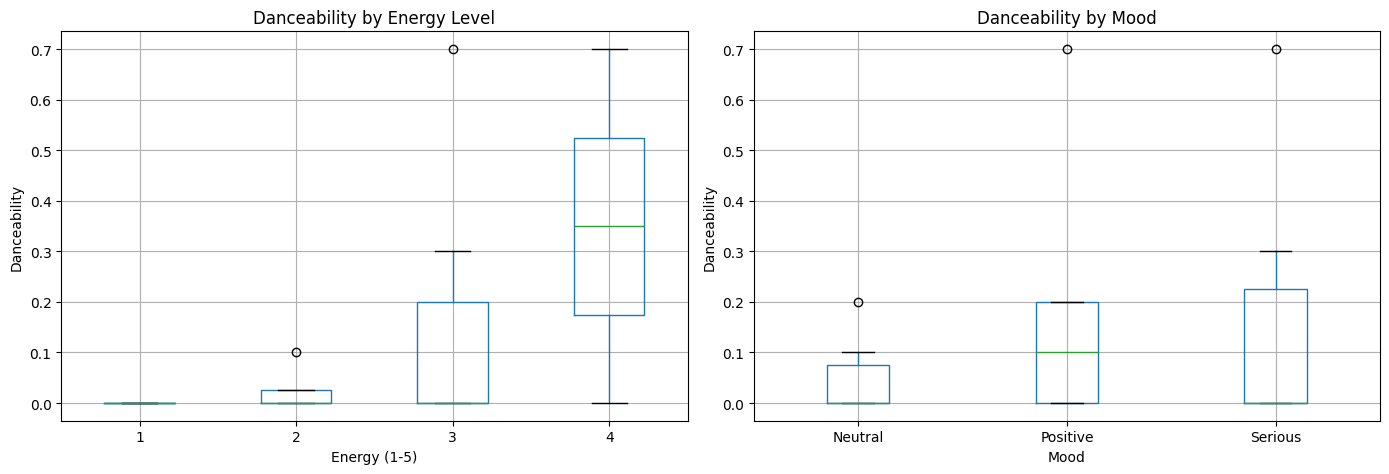


Correlation with energy_1_5:
danceability        0.400249
instrumentalness    0.222859
acousticness        0.146087
liveness            0.139686
speechiness        -0.265144
Name: energy_1_5, dtype: float64

Mean LLM features by mood:
          danceability  instrumentalness  acousticness  speechiness  liveness
mood                                                                         
Neutral           0.05              0.80          0.15         0.08      0.52
Positive          0.18              0.95          0.32         0.00      0.52
Serious           0.17              0.98          0.23         0.00      0.52


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Danceability by energy level
df_llm_features.boxplot(column='danceability', by='energy_1_5', ax=axes[0])
axes[0].set_title('Danceability by Energy Level')
axes[0].set_xlabel('Energy (1-5)')
axes[0].set_ylabel('Danceability')

# Danceability by mood
df_llm_features.boxplot(column='danceability', by='mood', ax=axes[1])
axes[1].set_title('Danceability by Mood')
axes[1].set_xlabel('Mood')
axes[1].set_ylabel('Danceability')

plt.suptitle('')
plt.tight_layout()
plt.show()

# Correlation between energy_1_5 and each LLM feature
llm_feature_cols = ['danceability', 'instrumentalness', 'acousticness', 'speechiness', 'liveness']
correlations = df_llm_features[['energy_1_5'] + llm_feature_cols].corr()['energy_1_5'].drop('energy_1_5')
print("\nCorrelation with energy_1_5:")
print(correlations.sort_values(ascending=False))

# Mean by mood
print("\nMean LLM features by mood:")
print(df_llm_features.groupby('mood')[llm_feature_cols].mean().round(2))

In [64]:
!pip install anthropic -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.0/457.0 kB 35.1 MB/s eta 0:00:00


In [65]:
import anthropic
import json
import re

client = anthropic.Anthropic(api_key=userdata.get('ANTHROPIC_API_KEY'))

def get_audio_features_claude(description):
    message = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=256,
        messages=[
            {
                "role": "user",
                "content": f"""You are a music supervisor choosing background music for an advertisement.
Given this ad description, estimate these audio features for the IDEAL BACKGROUND MUSIC:

- danceability: how groovy/rhythmic should the music be (0=ambient/slow, 1=highly danceable)
- instrumentalness: should music be instrumental or have vocals (0=needs vocals, 1=purely instrumental)
- acousticness: should music be acoustic or electronic (0=fully electronic, 1=fully acoustic)
- speechiness: should music have rap/spoken word elements (0=no, 1=yes heavily)
- liveness: should music feel like a live recording or polished studio (0=studio, 1=live)

Ad description: {description}

Think carefully about the specific tone, energy, and context of this ad. Return ONLY a JSON object with float values between 0.0 and 1.0, no other text."""
            }
        ]
    )

    text = message.content[0].text.strip()
    print(f"Raw output: {text}")

    match = re.search(r'\{.*?\}', text, re.DOTALL)
    if match:
        return json.loads(match.group())
    return None

# Run on same 18-ad sample for direct comparison
results_claude = []
for _, row in sample_ads.iterrows():
    print(f"\nAd: {row['ad_id']} | Energy={row['energy_1_5']} | Tempo={row['tempo']} | Mood={row['mood']}")
    print(f"Description: {row['ad_description']}")
    features = get_audio_features_claude(row['ad_description'])
    if features:
        results_claude.append({
            'ad_id': row['ad_id'],
            'energy_1_5': row['energy_1_5'],
            'tempo': row['tempo'],
            'mood': row['mood'],
            **features
        })

df_llm_claude = pd.DataFrame(results_claude)

# Same diagnostics as before for apples-to-apples comparison
llm_feature_cols = ['danceability', 'instrumentalness', 'acousticness', 'speechiness', 'liveness']
correlations = df_llm_claude[['energy_1_5'] + llm_feature_cols].corr()['energy_1_5'].drop('energy_1_5')
print("\nCorrelation with energy_1_5:")
print(correlations.sort_values(ascending=False))

print("\nMean LLM features by mood:")
print(df_llm_claude.groupby('mood')[llm_feature_cols].mean().round(2))


Ad: CN_035 | Energy=3 | Tempo=Medium | Mood=Neutral
Description: Camera pans around multiple traditional Subway sandwiches as they're being prepped; narrator comments on the 54g of protein per footlong sandwich; narrator also announces ongoing discount/deal
Raw output: {
  "danceability": 0.6,
  "instrumentalness": 0.8,
  "acousticness": 0.3,
  "speechiness": 0.1,
  "liveness": 0.2
}

Ad: CN_087 | Energy=2 | Tempo=Slow | Mood=Neutral
Description: Jennifer Coolidge is sitting next to Wayne Gretzky at a hockey game but doesn't recognize who he is. Her friend explains to her that Gretzky was accepted into the HoF, to which, she respond that her Discover card allows her into more places
Raw output: {
  "danceability": 0.3,
  "instrumentalness": 0.8,
  "acousticness": 0.4,
  "speechiness": 0.1,
  "liveness": 0.2
}

Ad: CS_057 | Energy=2 | Tempo=Medium | Mood=Neutral
Description: Different comedians standing in front of the camera as a narrator speaks about how they're "not funny" but "Hula

## 5: V5 - K-Means Clustering

This section explores an unsupervised clustering approach using K-means on the librosa PCA
feature space to pre-group tracks by audio profile, then matches ads to the nearest cluster
centroid before ranking within it.

### Steps
1. Apply K-means clustering to PCA-reduced librosa features
2. Determine optimal k (elbow method + silhouette score)
3. Assign each track to a cluster
4. Match each ad to nearest cluster centroid
5. Rank tracks within matched cluster by Euclidean distance
6. Compare v3 vs v1/v2 results on same 300 ads
7. Save `v3_matches_with_meta.csv` to S3

### Evaluation Metrics

| Metric | Target | V1 Result | V2 Result | V3 Result |
|--------|--------|-----------|-----------|-----------|
| Coverage (≥10 matches per ad) | >90% | 100% | 100% | TBD |
| Artist diversity (unique per top-10) | >0.7 | 0.995 | 0.995 | TBD |
| Match score range | <0.3 | 0.004–0.099 | 0.025–0.106 | TBD |
| Human listening score | >3.5/5 | TBD | TBD | TBD |

&nbsp;

## 6: V6 - Neural Clustering (Stretch Goal)

This section explores deep neural clustering methods to learn a richer latent representation
of audio features. Candidate approaches include autoencoder-based clustering, Deep Embedded
Clustering (DEC), or a Variational Autoencoder (VAE).

### Steps
1. Select neural clustering architecture (autoencoder / DEC / VAE)
2. Train model on FMA librosa + PCA feature space
3. Extract learned latent embeddings
4. Cluster in latent space and assign tracks
5. Match ads to nearest cluster, rank within cluster
6. Compare v4 vs all prior versions on same 300 ads
7. Save `v4_matches_with_meta.csv` to S3

### Evaluation Metrics

| Metric | Target | V1 Result | V2 Result | V3 Result | V4 Result |
|--------|--------|-----------|-----------|-----------|-----------|
| Coverage (≥10 matches per ad) | >90% | 100% | 100% | TBD | TBD |
| Artist diversity (unique per top-10) | >0.7 | 0.995 | 0.995 | TBD | TBD |
| Match score range | <0.3 | 0.004–0.099 | 0.025–0.106 | TBD | TBD |
| Human listening score | >3.5/5 | TBD | TBD | TBD | TBD |

&nbsp;